# Notebook 2: Mathematical Specification and Scalar Forward Propagation
## Neural Network from Scratch: Binary MNIST Classification

## 1. Notebook Overview
In Notebook 1, we prepared the MNIST dataset for binary classification by retaining only images representing the digits (0) and (1). We also reshaped and normalized the images so that they could eventually be passed into a neural network.


Before training a neural network, however, we need to understand exactly how a prediction is computed.


This notebook focuses exclusively on **forward propagation**, which is the process of moving information from the input layer through the hidden layer and finally to the output layer.


We will intentionally begin with scalar calculations and explicit Python loops rather than immediately using NumPy matrix multiplication. Although loops are computationally inefficient, they make every multiplication and addition visible.


The notebook follows this sequence:
1. Define a one-hidden-layer neural-network architecture.
2. specify the dimensions of every input, weight, bias, and activation;
3. derive the forward-propagation equations;
4. implement one neuron using scalar operations;
5. extend the implementation to an entire hidden layer using loops;
6. manually verify the loop implementation on a small synthetic example;
7. confirm the loop implementation using vectorized NumPy calculations;
8. apply the scalar implementation to one MNIST image.
   
At this stage, the network will use randomly initialized parameters. **Therefore, it is not expected to classify MNIST images accurately yet.**


The goal is to understand the computation that produces a prediction.

## 2. Import Required Libraries
We will use:
- NumPy for numerical operations and parameter storage;
- Matplotlib for displaying an MNIST image.

Although NumPy supports efficient matrix multiplication, the primary implementation in this notebook will use explicit loops.

In [3]:
import numpy as np 
import matplotlib.pyplot as plt

## 3. Reproducibility
### Explanation
Neural-network weights are usually initialized randomly.
Without a fixed random seed, the initial weights would change whenever the notebook is rerun. That would cause the network's initial outputs to change as well.

Setting a seed gives us reproducible results:
$$
\text{same random seed}
\Longrightarrow
\text{same initial weights}
\Longrightarrow
\text{same initial predictions}.
$$
Reproducibility will be especially important later when we compare:
- scalar Python loops;
- vectorized NumPy operations;
- a TensorFlow implementation.

# Part I: Mathematical Specification
## 4. Define the Binary Classification Problem
Each original MNIST image contains $(28 \times 28)$ grayscale pixels.
After flattening an image, one observation becomes a vector containing
$
28 \times 28 = 784
$
input values.
We write one input image as
$$
\begin{bmatrix}
x_1 \
\\
x_2 \
\\
\vdots \
\\
x_{784}
\end{bmatrix}
\in \mathbb{R}^{784}.
$$
Each normalized pixel value satisfies
$$
0 \leq x_j \leq 1.
$$
The target variable is
$$
y =
\begin{cases}
0, & \text{if the image represents digit 0},\
\\
1, & \text{if the image represents digit 1}.
\end{cases}
$$
The neural network will produce an output
$$
\hat{y} \in (0,1),
$$
which we interpret as
$$
P(y=1 \mid \mathbf{x}).
$$
For example:
- $\hat{y}=0.03$ means the model assigns a low probability to digit (1);
- $\hat{y}=0.92$ means the model assigns a high probability to digit (1).
  
A decision threshold of (0.5) can later convert this probability into a predicted class:
$$
\begin{cases}
0, & \hat{y}<0.5,\
\\
1, & \hat{y}\geq 0.5.
\end{cases}
$$

## 5. Define a One-Hidden-Layer Architecture
We will use the following neural-network architecture:
$$
784 \longrightarrow H \longrightarrow 1.
$$
The three layers are:
1. an input layer containing 784 pixel values;
2. one hidden layer containing (H) neurons;
3. one output neuron for binary classification.

For the initial MNIST implementation, we will choose
$
H=8.
$
Therefore, the architecture is
$$
784 \longrightarrow 8 \longrightarrow 1.
$$

This is intentionally a small network.
The hidden layer is large enough to demonstrate how multiple neurons work together, while remaining small enough for us to inspect individual calculations.

In [4]:
input_size = 784 
hidden_size = 8 
output_size = 1 
print("Input units:", input_size) 
print("Hidden units:", hidden_size) 
print("Output units:", output_size)

Input units: 784
Hidden units: 8
Output units: 1


## 6. Layer Notation
We use superscripts to identify the neural-network layer.
- Layer (0): input layer
- Layer (1): hidden layer
- Layer (2): output layer

The input vector is also treated as the activation of layer (0):
$$
\mathbf{a}^{(0)}=\mathbf{x}.
$$

For the hidden layer, we first calculate the linear component:

$$
\mathbf{W}^{(1)}\mathbf{x}
+
\mathbf{b}^{(1)}.
$$
We then apply an activation function:

$$
\sigma\left(\mathbf{z}^{(1)}\right).
$$
For the output layer:

$$
\mathbf{W}^{(2)}\mathbf{a}^{(1)}
+
b^{(2)}.
$$
Finally,

$$
\sigma\left(z^{(2)}\right).
$$
Because there is only one output neuron, we identify the final activation with the prediction:
$$
\hat{y}=a^{(2)}.
$$

## 7. Difference Between (z) and (a)
For every neuron, two values are important.
### Pre-activation value
The pre-activation value is the weighted sum before applying the activation function:
$$
\sum_j w_jx_j+b.
$$
### Activation value
The activation value is the output after applying the activation function:
$$
a=\sigma(z).
$$
Therefore, a neuron performs two conceptual steps:
$$
\text{weighted sum}
\longrightarrow
\text{activation function}.
$$
More explicitly,
$$
x_1,\ldots,x_D
\quad\longrightarrow\quad
z
\quad\longrightarrow\quad
a.
$$
The distinction will become important during backpropagation because gradients pass through both the linear operation and the activation function.

## 8. Dimensions of the Input Vector
Let
$
D=784
$
be the number of input features and let
$
H=8
$
be the number of hidden neurons.
For one MNIST observation:
$$
\mathbf{x}\in\mathbb{R}^{D}.
$$
With $D=784$,
$$
\mathbf{x}\in\mathbb{R}^{784}.
$$
In NumPy, its shape will be
$(784,)$
This means it is a one-dimensional array containing 784 values.


## 9. Dimensions of the Hidden-Layer Weights
Every hidden neuron receives all 784 input values.
The weight connecting input feature (j) to hidden neuron (i) is written as
$$
w_{ij}^{(1)}.
$$
The first index identifies the destination neuron, while the second index identifies the input feature:
$$
\text{weight from input } j
\text{ to hidden neuron } i.
$$
For one hidden neuron, we need 784 weights.
For (H) hidden neurons, we need
$
H \times 784
$
weights.
The hidden-layer weight matrix is therefore
$$
\mathbf{W}^{(1)}
\in
\mathbb{R}^{H\times D}.
$$
For our architecture,
$$
\mathbf{W}^{(1)}
\in
\mathbb{R}^{8\times784}.
$$
Its NumPy shape is
(8, 784)
Each row corresponds to one hidden neuron:
$$
\begin{bmatrix}
& \mathbf{w}^{(1)}_1 &
\\
& \mathbf{w}^{(1)}_2 & 
\\
& \vdots &\
\\
& \mathbf{w}^{(1)}_8 & 
\end{bmatrix}.
$$
Each row contains the 784 weights used by one hidden neuron.

## 10. Dimensions of the Hidden-Layer Biases
Each hidden neuron has one bias value.
Therefore,
$$
\mathbf{b}^{(1)}
\in
\mathbb{R}^{H}.
$$
For $H=8$,
$$
\mathbf{b}^{(1)}
\in
\mathbb{R}^{8}.
$$
Its NumPy shape is
$(8,)$
The (i)-th bias belongs to the (i)-th hidden neuron:
$$
\text{bias of hidden neuron }i.
$$
The hidden-layer pre-activation vector is therefore
$$
\mathbf{W}^{(1)}\mathbf{x}
+
\mathbf{b}^{(1)}.
$$
Dimensionally,
$$
(H\times D)(D)+(H)=(H).
$$
For the MNIST network:
$$
(8\times784)(784)+(8)=(8).
$$
Thus,
$$
\mathbf{z}^{(1)}\in\mathbb{R}^{8}.
$$
After applying the activation function,
$$
\sigma(\mathbf{z}^{(1)})
\in
\mathbb{R}^{8}.
$$

## 11. Dimensions of the Output-Layer Weights
The output neuron receives all (H) hidden-layer activations.
It therefore requires one weight for each hidden neuron.
We write the output-layer weight vector as
$$
\mathbf{W}^{(2)}
\in
\mathbb{R}^{1\times H}.
$$
For $H=8$,
$$
\mathbf{W}^{(2)}
\in
\mathbb{R}^{1\times8}.
$$
For a scalar loop implementation, we may store it as a one-dimensional NumPy array with shape
$(8,)$
The weight
$
w_i^{(2)}
$
connects hidden neuron (i) to the output neuron.
The output neuron also has one scalar bias:
$$
b^{(2)}\in\mathbb{R}.
$$
The output pre-activation is
$$
\sum_{i=1}^{H}
w_i^{(2)}a_i^{(1)}
+
b^{(2)}.
$$
Because the output layer has one neuron,
$
z^{(2)}
$
is a scalar.
After applying the sigmoid function,
$$
\sigma\left(z^{(2)}\right)
$$
is also a scalar.

## 12. Parameter Dimensions

| Quantity | Meaning | Shape |
| --- | --- | --- |
|$\mathbf{x}$|Input vector | $((784,))$ |
|$\mathbf{W}^{(1)}$|Input-to-hidden weights|$((8,784))$
|$\mathbf{b}^{(1)}$|Hidden biases|$((8,))$|
|$\mathbf{z}^{(1)}$|Hidden pre-activations|$((8,))$|
|$\mathbf{a}^{(1)}$|Hidden activations|$((8,))$|
|$\mathbf{W}^{(2)}$|Hidden-to-output weights|$((8,))$|
|$b^{(2)}$|Output bias|scalar|
|$z^{(2)}$|Output pre-activation|scalar|
|$\hat y$|Predicted probability|scalar|

## 13. Parameter Count
The hidden layer contains
$
HD
$
weights and
$
H
$
biases.
The output layer contains
$
H
$
weights and one bias.
Therefore, the total number of trainable parameters is
$$
HD+H+H+1.
$$
This can be simplified to
$$
HD+2H+1.
$$
For $D=784$ and $H=8$,
$$
6272+16+1=6289
$$

In [8]:
hidden_weight_count = hidden_size * input_size 
hidden_bias_count = hidden_size 
output_weight_count = hidden_size * 1
output_bias_count = 1 
total_parameter_count = (hidden_weight_count + hidden_bias_count + output_weight_count + output_bias_count) 

print("Hidden weights:", hidden_weight_count) 
print("Hidden biases:", hidden_bias_count) 
print("Output weights:", output_weight_count) 
print("Output biases:", output_bias_count) 
print("Total parameters:", total_parameter_count)

Hidden weights: 6272
Hidden biases: 8
Output weights: 8
Output biases: 1
Total parameters: 6289


# Part II: Activation Function
## 14. Define the Sigmoid Function
For this binary-classification network, we will use the sigmoid activation function:
$$
g(z) = \frac{1}{1+e^{-z}}.
$$
The sigmoid function maps any real number to the interval
$
(0,1).
$
This makes it suitable for the output neuron because the final activation can be interpreted as a probability.

In [10]:
def sigmoid(z):
    """
    z : float or np.ndarray
        Pre-activation value or values.

    Returns
    float or np.ndarray
        Sigmoid activation.
    """
    return 1.0 / (1.0 + np.exp(-z))
    
## Test the function:
test_values = np.array([-5.0, -1.0, 0.0, 1.0, 5.0])
sigmoid_values = sigmoid(test_values)

for z, activation in zip(test_values, sigmoid_values):
    print(f"sigmoid({z:>4.1f}) = {activation:.6f}")

sigmoid(-5.0) = 0.006693
sigmoid(-1.0) = 0.268941
sigmoid( 0.0) = 0.500000
sigmoid( 1.0) = 0.731059
sigmoid( 5.0) = 0.993307


### Analysis
The sigmoid function has several important properties:
$$
\sigma(0)=0.5.
$$
When (z) is strongly positive,
$$
\sigma(z)\approx1.
$$
When (z) is strongly negative,
$$
\sigma(z)\approx0.
$$
Thus, the weighted sum (z) controls whether the neuron produces a value close to 0, close to 1, or somewhere between them.

### 15. Visualize the Sigmoid Function

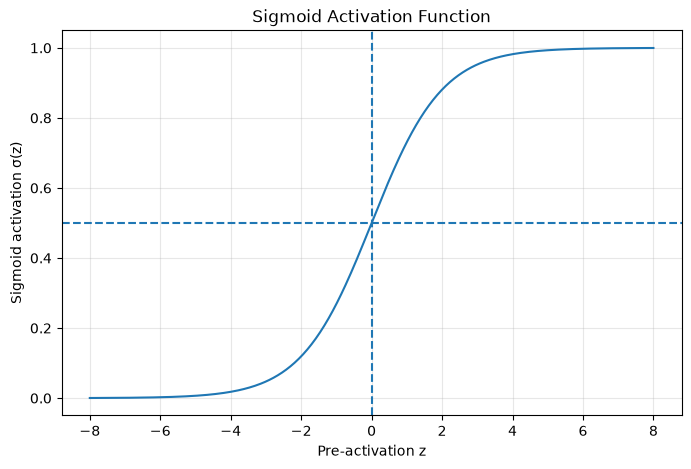

In [13]:
z_grid = np.linspace(-8, 8, 400) 
activation_grid = sigmoid(z_grid) 

plt.figure(figsize=(8, 5)) 
plt.plot(z_grid, activation_grid) 
plt.axhline(0.5, linestyle="--") 
plt.axvline(0.0, linestyle="--") 
plt.xlabel("Pre-activation z") 
plt.ylabel("Sigmoid activation σ(z)") 
plt.title("Sigmoid Activation Function") 
plt.grid(alpha=0.3) 
plt.show()

### Analysis
The sigmoid function is nonlinear.
Without a nonlinear activation function, multiple neural-network layers would collapse into a single linear transformation. The hidden layer would therefore not provide additional representational power.
The sigmoid transformation allows hidden neurons to learn nonlinear combinations of input pixels.

# Part III: Forward Propagation Through One Neuron
## 16. Mathematical Definition of a Single Neuron
Suppose one neuron receives (D) input features:
$$
x_1,x_2,\ldots,x_D.
$$
The neuron also has:
one weight (w_j) for each input feature;
one bias (b).
The weighted sum is
$$
w_1x_1+w_2x_2+\cdots+w_Dx_D+b.
$$
Using summation notation,
$$
\sum_{j=1}^{D}w_jx_j+b.
$$
The neuron output is
$$
a=\sigma(z).
$$
The forward calculation is therefore
$$
\sigma\left(
\sum_{j=1}^{D}w_jx_j+b
\right)
$$

## 17. Implement One Neuron With an Explicit Loop

In [14]:
def single_neuron_forward_loop(x, weights, bias):
    """
    Compute the forward pass of one sigmoid neuron using explicit loops.

    x : np.ndarray, shape (D,)
        Input feature vector.

    weights : np.ndarray, shape (D,)
        Weight associated with each input feature.

    bias : float
        Neuron bias.

    Returns
    z : float
        Pre-activation weighted sum.

    activation : float
        Sigmoid activation.
    """
    if x.ndim != 1:
        raise ValueError("x must be a one-dimensional array.")

    if weights.ndim != 1:
        raise ValueError("weights must be a one-dimensional array.")

    if len(x) != len(weights):
        raise ValueError(
            "x and weights must contain the same number of elements."
        )

    z = float(bias)

    for j in range(len(x)):
        z += float(weights[j]) * float(x[j])

    activation = float(sigmoid(z))

    return z, activation

## 18. Test the Single-Neuron Function
Consider the following small input:
$$
\begin{bmatrix}
0.5\
1.0\
-0.5
\end{bmatrix}.
$$
Let the weights be
$$
\begin{bmatrix}
0.2\
-0.4\
0.6
\end{bmatrix}
$$
and the bias be
$$
b=0.1.
$$

In [16]:
x_single = np.array([0.5, 1.0, -0.5])
weights_single = np.array([0.2, -0.4, 0.6])
bias_single = 0.1

z_single, activation_single = single_neuron_forward_loop(
    x=x_single,
    weights=weights_single,
    bias=bias_single
)

print("Pre-activation z:", z_single)
print("Activation a:", activation_single)


Pre-activation z: -0.5
Activation a: 0.3775406687981454


## 19. Manually Verify the Single Neuron
The weighted sum is
$$
(0.2)(0.5)
+
(-0.4)(1.0)
+
(0.6)(-0.5)
+
0.1.
$$
Calculate each weighted input separately:
$$
(0.2)(0.5)=0.1,
$$
$$
(-0.4)(1.0)=-0.4,
$$
$$
(0.6)(-0.5)=-0.3.
$$
Therefore,
$$
0.1-0.4-0.3+0.1=
-0.5.
$$
Apply the sigmoid function:
$$
\sigma(-0.5)=
\frac{1}{1+e^{0.5}}
\approx
0.3775407.
$$
The loop implementation therefore agrees with the manual calculation.


## 20. Inspect Every Contribution to the Neuron

In [17]:
running_total = bias_single

print(f"Initial value from bias: {running_total:.4f}")

for j in range(len(x_single)):
    contribution = weights_single[j] * x_single[j]
    running_total += contribution

    print(
        f"Feature {j}: "
        f"{weights_single[j]:.4f} × {x_single[j]:.4f} "
        f"= {contribution:.4f}; "
        f"running z = {running_total:.4f}"
    )

print(f"\nFinal z = {running_total:.4f}")
print(f"sigmoid(z) = {sigmoid(running_total):.6f}")


Initial value from bias: 0.1000
Feature 0: 0.2000 × 0.5000 = 0.1000; running z = 0.2000
Feature 1: -0.4000 × 1.0000 = -0.4000; running z = -0.2000
Feature 2: 0.6000 × -0.5000 = -0.3000; running z = -0.5000

Final z = -0.5000
sigmoid(z) = 0.377541


### Analysis
A neuron does not treat every feature equally.
Each weight controls how strongly an input contributes to the result:
- a positive weight increases (z) when the corresponding input is positive;
- a negative weight decreases (z) when the corresponding input is positive;
- a weight near zero causes the feature to have little influence;
- the bias shifts the weighted sum independently of the input.
  
During training, the neural network will adjust these weights and biases to improve its predictions.

# Part IV: Forward Propagation Through a Hidden Layer
## 21. Scalar Equation for Hidden Neuron (i)
Suppose the hidden layer contains (H) neurons.
For hidden neuron (i), the pre-activation is
$$
\sum_{j=1}^{D}
w_{ij}^{(1)}x_j
+
b_i^{(1)}.
$$
Its activation is
$$
\sigma\left(z_i^{(1)}\right).
$$
This process is repeated for every hidden neuron:
$$
i=1,2,\ldots,H.
$$
Each hidden neuron uses the same input vector $(\mathbf{x})$, but it has its own:
- weight vector;
- bias;
- pre-activation;
- activation.

## 22. Hidden-Layer Matrix Equation
The collection of scalar equations can be written compactly as
$$
\mathbf{z}^{(1)}=\
\mathbf{W}^{(1)}\mathbf{x}
+
\mathbf{b}^{(1)}.
$$
Applying sigmoid element by element gives
$$
\sigma\left(\mathbf{z}^{(1)}\right).
$$

However, we will first implement these equations using nested loops rather than matrix multiplication.

## 23. Implement the Hidden Layer With Explicit Loops

In [18]:
def hidden_layer_forward_loop(x, W1, b1):
    """
    x : np.ndarray, shape (D,)
        Input vector.

    W1 : np.ndarray, shape (H, D)
        Hidden-layer weight matrix.

    b1 : np.ndarray, shape (H,)
        Hidden-layer bias vector.

    Returns
    z1 : np.ndarray, shape (H,)
        Hidden-layer pre-activations.

    a1 : np.ndarray, shape (H,)
        Hidden-layer sigmoid activations.
    """
    if x.ndim != 1:
        raise ValueError("x must be one-dimensional.")

    if W1.ndim != 2:
        raise ValueError("W1 must be two-dimensional.")

    if b1.ndim != 1:
        raise ValueError("b1 must be one-dimensional.")

    hidden_units, input_features = W1.shape

    if len(x) != input_features:
        raise ValueError(
            "The number of elements in x must match "
            "the number of columns in W1."
        )

    if len(b1) != hidden_units:
        raise ValueError(
            "The number of biases must match "
            "the number of rows in W1."
        )

    z1 = np.zeros(hidden_units, dtype=float)
    a1 = np.zeros(hidden_units, dtype=float)

    for i in range(hidden_units):
        z1[i] = float(b1[i])

        for j in range(input_features):
            z1[i] += float(W1[i, j]) * float(x[j])

        a1[i] = float(sigmoid(z1[i]))

    return z1, a1


### Explanation of the Outer Loop
The outer loop iterates across hidden neurons.
Each iteration computes one hidden neuron's output.
The row
$W1[i, :]$
contains all weights belonging to hidden neuron (i).

### Explanation of the Inner Loop
The inner loop iterates across input features.
For every input feature, the function calculates
$
w_{ij}^{(1)}x_j
$
and adds it to the current hidden neuron's weighted sum.
Thus, the nested loops correspond to
$$
\text{for every hidden neuron }i:
\quad
\text{sum across every input feature }j.
$$


# Part V: Output-Layer Forward Propagation
## 24. Scalar Equation for the Output Neuron
Once all hidden activations have been calculated, the output neuron receives
$$
a_1^{(1)},
a_2^{(1)},
\ldots,
a_H^{(1)}.
$$
The output pre-activation is
$$
\sum_{i=1}^{H}
w_i^{(2)}a_i^{(1)}
+
b^{(2)}.
$$
The final output is
$$
\sigma\left(z^{(2)}\right).
$$

## 25. Implement the Output Neuron With a Loop

In [19]:
def output_layer_forward_loop(a1, W2, b2):
    """
    a1 : np.ndarray, shape (H,)
        Hidden-layer activations.

    W2 : np.ndarray, shape (H,)
        Output-layer weights.

    b2 : float
        Output-layer bias.

    Returns
    z2 : float
        Output pre-activation.

    y_hat : float
        Predicted probability.
    """
    if a1.ndim != 1:
        raise ValueError("a1 must be one-dimensional.")

    if W2.ndim != 1:
        raise ValueError("W2 must be one-dimensional.")

    if len(a1) != len(W2):
        raise ValueError(
            "a1 and W2 must contain the same number of elements."
        )

    z2 = float(b2)

    for i in range(len(a1)):
        z2 += float(W2[i]) * float(a1[i])

    y_hat = float(sigmoid(z2))

    return z2, y_hat


## 26. Combine Both Layers Into a Complete Forward Pass

In [21]:
def forward_propagation_loop(x, W1, b1, W2, b2):
    """
    x : np.ndarray, shape (D,)
        Input vector.

    W1 : np.ndarray, shape (H, D)
        Input-to-hidden weights.

    b1 : np.ndarray, shape (H,)
        Hidden-layer biases.

    W2 : np.ndarray, shape (H,)
        Hidden-to-output weights.

    b2 : float
        Output bias.

    Returns
    cache : dict
        Intermediate values and final prediction.
    """
    z1, a1 = hidden_layer_forward_loop(x, W1, b1)
    z2, y_hat = output_layer_forward_loop(a1, W2, b2)

    cache = {
        "x": x,
        "z1": z1,
        "a1": a1,
        "z2": z2,
        "y_hat": y_hat
    }

    return cache

### Why Return a Cache?
The dictionary stores the intermediate values:
$$
\mathbf{x},
\quad
\mathbf{z}^{(1)},
\quad
\mathbf{a}^{(1)},
\quad
z^{(2)},
\quad
\hat{y}.
$$

These values will be required later during backpropagation.
Instead of recomputing them, we preserve them during the forward pass.